# 04 — Retrieval Experiments

**Experiments D01/D02/D07 (WBS T023).** Oracle proved the model reasons well when handed perfect evidence (96.7%/95.3%). This notebook asks the next question: can we actually *find* that evidence automatically? Compares chunking strategy (clause-aware vs fixed-size), chunk size, and top-K, scored with Evidence Recall@K, precision, and MRR.

Entirely local (embeddings + FAISS, no LLM calls) - `scripts/run_retrieval_experiments.py` ran the full dev split's Entailment/Contradiction cases (614 cases, NotMentioned excluded since it has no gold evidence to recall) across 5 configs. This notebook loads the saved comparison and adds the chart + the reasoning behind the final pick.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
apply_style()

results = json.loads(Path("data/retrieval_experiment_results.json").read_text())
df = pd.DataFrame(results).set_index("label")
df

,recall,precision,mrr,n_cases,elapsed_s
label,,,,,
clause_512_k5 (default),0.936876,0.031842,0.190757,614,27.610123
fixed_512_k5,0.952742,0.030764,0.187504,614,21.915348
clause_256_k5,0.852921,0.056507,0.282941,614,31.384540
clause_512_k3,0.838716,0.040402,0.189101,614,22.508192
clause_512_k10,0.994969,0.027563,0.191329,614,22.462775


## Why recall alone is misleading here

Every config clears the planning doc's 70% Evidence Recall@K target - some by a lot (99.5% for `clause_512_k10`). But that's largely an artifact of document length, not retrieval skill: the median dev document is ~2,300 tokens, so a 512-token chunk size gives most documents only **4-8 chunks total**. Retrieving "top-10" from a document that only *has* 5-8 chunks means returning almost the entire document - that's not filtering, it's dumping.

**MRR is the more honest signal.** It measures whether the true evidence chunk ranks *near the top* of what's retrieved, not just whether it appears *somewhere* in a near-complete document. That's what actually matters once RAG has to hand a *small* number of chunks to the classifier (for cost and context-window reasons), not the whole document.

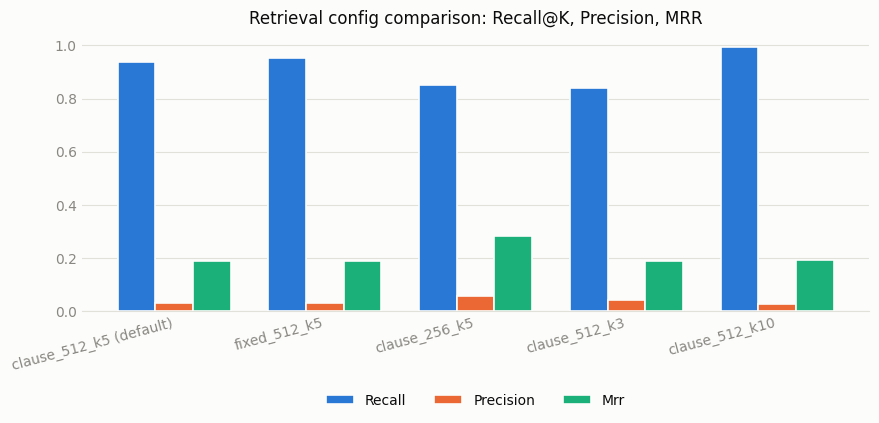

In [2]:
metrics = ["recall", "precision", "mrr"]
metric_colors = {m: CATEGORICAL_SLOTS[i] for i, m in enumerate(metrics)}
labels = df.index.tolist()
x = range(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, metric in enumerate(metrics):
    values = df[metric].tolist()
    ax.bar([xi + i * width for xi in x], values, width,
           label=metric.capitalize(), color=metric_colors[metric], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval config comparison: Recall@K, Precision, MRR")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/retrieval_config_comparison.png", **savefig_kwargs())
plt.show()

## Finding

`clause_256_k5` (smaller clause-aware chunks) has the **best MRR (0.283)** and the **best precision (0.057)** of any config, despite having the *lowest* raw recall (85.3% vs. up to 99.5% elsewhere). Smaller chunks let the retriever actually discriminate the relevant clause from the rest of the document, instead of every top-K query just returning almost everything.

`clause_512_k10`'s 99.5% recall is real but hollow: with only ~5-8 chunks per typical document, k=10 usually *is* the whole document - it isn't demonstrating retrieval skill, just document shortness.

## Decision

**Retrieval config for RAG: clause-aware chunking, chunk_size=256, top_k=5** - optimizing for ranking quality (MRR), not raw recall, since RAG needs to select a *small* number of genuinely relevant chunks, not recover the whole document. Recorded as an ADR in `CLAUDE.md`'s Decisions Log alongside the model choice.